In [1]:
import numpy as np

X_train = np.load("../dataset/processed/X_train.npy")
X_test = np.load("../dataset/processed/X_test.npy")

y_train = np.load("../dataset/processed/y_train.npy")
y_test = np.load("../dataset/processed/y_test.npy")

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [3]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

d:\Projects\DeepShield\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 39s 786ms/step - accuracy: 0.5356 - loss: 1.1323 - val_accuracy: 0.5015 - val_loss: 0.6930
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 599ms/step - accuracy: 0.5540 - loss: 0.6914 - val_accuracy: 0.5413 - val_loss: 0.6883
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 799ms/step - accuracy: 0.6314 - loss: 0.6559 - val_accuracy: 0.5199 - val_loss: 0.6993
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 30s 724ms/step - accuracy: 0.7057 - loss: 0.5874 - val_accuracy: 0.5719 - val_loss: 0.6929
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 32s 783ms/step - accuracy: 0.7962 - loss: 0.4838 - val_accuracy: 0.5902 - val_loss: 0.7626
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 30s 729ms/step - accuracy: 0.8598 - loss: 0.3353 - val_accuracy: 0.5474 - val_loss: 0.9047
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 31s 759ms/step - accuracy: 0.9172 - loss: 0.2240 - val_accuracy: 0.5566 - val_loss: 1.1286
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 30s 726ms/step - accuracy: 0.9617 - loss: 0.1343 - val_accu

In [6]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.5746 - loss: 1.7299
Test Accuracy: 0.5745721459388733


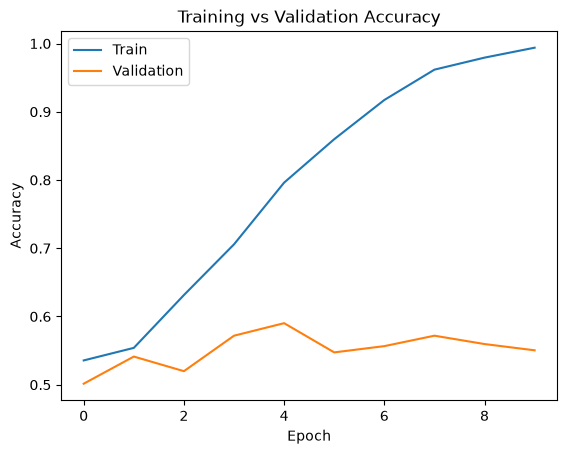

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

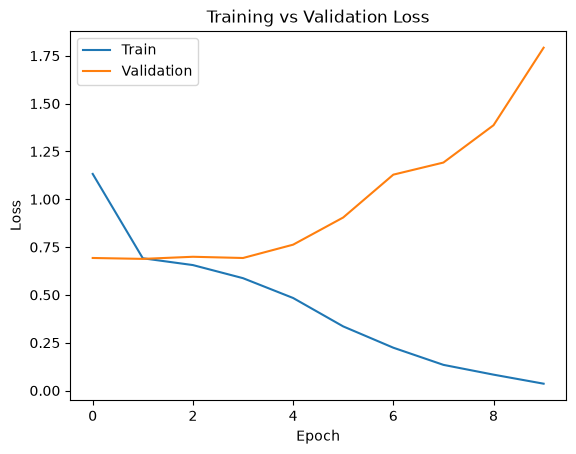

In [8]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

In [9]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

print(cm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step
[[118  99]
 [ 75 117]]


In [10]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.61      0.54      0.58       217
           1       0.54      0.61      0.57       192

    accuracy                           0.57       409
   macro avg       0.58      0.58      0.57       409
weighted avg       0.58      0.57      0.57       409



In [11]:
model.save("../model/deepshield_model.keras")

print("Model Saved!")

Model Saved!


In [12]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

print(cm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 301ms/step
[[118  99]
 [ 75 117]]


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.54      0.58       217
           1       0.54      0.61      0.57       192

    accuracy                           0.57       409
   macro avg       0.58      0.58      0.57       409
weighted avg       0.58      0.57      0.57       409

